# Quickstart

This workflow is for a user who wants to use a basic linear model without tuning and would like to generate and plot uncertainty bounds for a weather forecast of a specific city.

### Imports

In [1]:
from fue.config import Config
from fue.data import Data
from fue.forecast import Forecast
from fue.models import LinearUncertaintyModel, MLUncertaintyModel

### Data Workflow

Initialize Configuration (using the default settings from config.json) and Data objects

In [2]:
config = Config()
data = Data()

Read the historical raw dataset from disk to train a quick baseline model

In [3]:
data.read_raw()
dataset = data.generate_dataset()

### Train a Linear Model

Extract the configured feature and target column names

In [4]:
features = config.default_feature_columns
targets = config.default_target_columns

In [5]:
linear_model = LinearUncertaintyModel(config=config)
linear_model.fit(dataset, features, targets)

### Train a Machine Learning Model

In [6]:
ml_model = MLUncertaintyModel(
    config=config, hidden_layer_sizes=(32, 16), max_iter=1000, alpha=0.01, ensemble_size=5, seed=42
)
ml_model.fit(dataset, features, targets)

### Generate a Forecast
... for a specific city and for a certain number of days

In [7]:
forecast = Forecast()
forecast.fetch_forecast(location_name="aachen", forecast_days=14, past_days=0)

Use the uncertainty model to estimate uncertainty bounds and visualize them

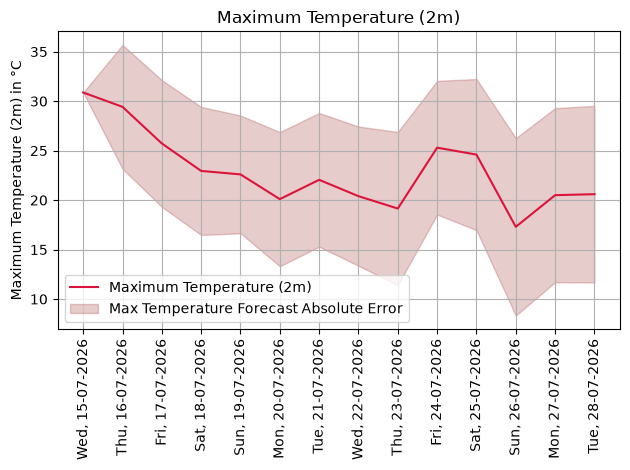

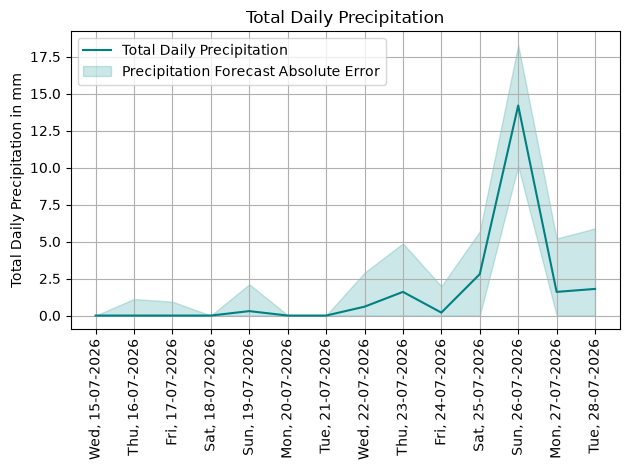

In [8]:
forecast.compute_uncertainties(linear_model)
forecast.plot(target_variables=["abs_diff__temperature_2m_max", "abs_diff__precipitation_sum"])

Now, we plot the uncertainty bounds using the machine learning model

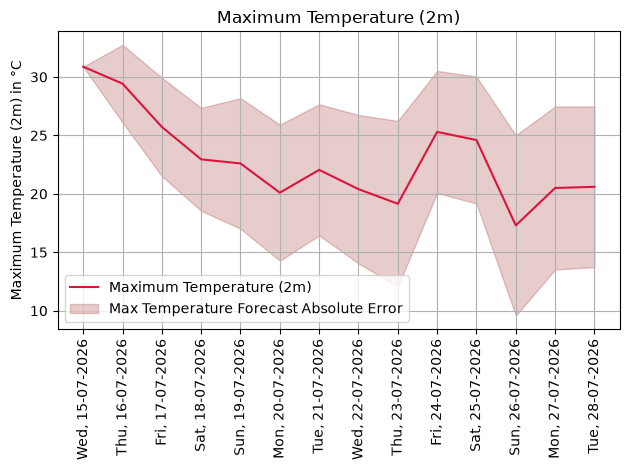

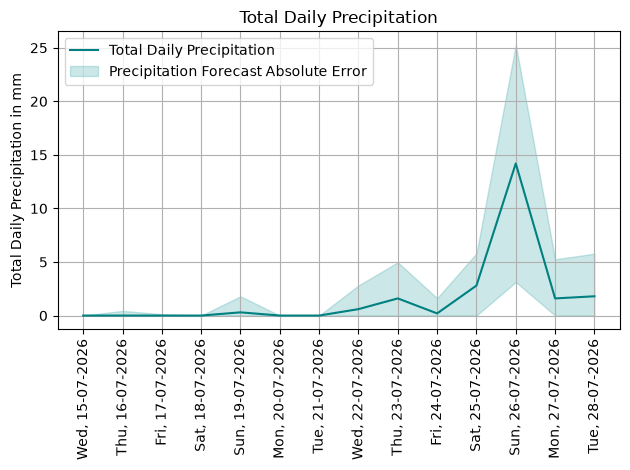

In [9]:
forecast.compute_uncertainties(ml_model)
forecast.plot(target_variables=["abs_diff__temperature_2m_max", "abs_diff__precipitation_sum"])